#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

import time

#### Import Datasets

In [2]:
%store -r Set1_X_Train
%store -r Set1_X_Test

%store -r Set1_y_Train
%store -r Set1_y_Test

#### LInear Regression

In [3]:
start = time.time()

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

lr = LinearRegression()

param_grid = {
    'fit_intercept': [True, False],
    'copy_X': [True, False],
    'n_jobs': [None, -1],  
    'positive': [True, False],
}

grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

grid_search.fit(Set1_X_Train, Set1_y_Train_array)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

neg_mse = grid_search.best_score_
print("Negative Mean Squared Error:", neg_mse)

linear_reg = grid_search.best_estimator_
end_train = time.time()  

linear_reg_pred_train = linear_reg.predict(Set1_X_Train)
end_predict = time.time()
linear_reg_pred_test = linear_reg.predict(Set1_X_Test)
end_predict_test = time.time()

linear_reg_pred_train_int = linear_reg_pred_train.astype(int)
linear_reg_pred_test_int = linear_reg_pred_test.astype(int)

Best Parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}
Negative Mean Squared Error: -2053.013895892609


#### Linear Regression Evaluation

In [4]:
# Mean Squared Error
mse_train = mean_squared_error(Set1_y_Train_array, linear_reg_pred_train_int)
mse_test = mean_squared_error(Set1_y_Test_array, linear_reg_pred_test_int)

# Root Mean Squared Error
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

# Mean Absolute Error
mae_train = mean_absolute_error(Set1_y_Train_array, linear_reg_pred_train_int)
mae_test = mean_absolute_error(Set1_y_Test_array, linear_reg_pred_test_int)

# R2 Score
r2_train = r2_score(Set1_y_Train_array, linear_reg_pred_train_int)
r2_test = r2_score(Set1_y_Test_array, linear_reg_pred_test_int)

# Time
fit_time = end_train - start
predict_time_train = end_predict - end_train
predict_time_test = end_predict_test - end_predict
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train)
print("Root Mean Squared Error:", rmse_train)
print("Mean Absolute Error:", mae_train)
print("R-squared Score:", r2_train)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test)
print("Root Mean Squared Error:", rmse_test)
print("Mean Absolute Error:", mae_test)
print("R-squared Score:", r2_test)

# Time
print("\n--Fit, Training Times--")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(predict_time_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(predict_time_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 1992.7066065629392
Root Mean Squared Error: 44.63974245627924
Mean Absolute Error: 33.99185691435219
R-squared Score: 0.5799841798894828

--Testing Set Evaluation--
Mean Squared Error: 1000.95
Root Mean Squared Error: 31.63779385481864
Mean Absolute Error: 25.19
R-squared Score: 0.420367351420165

--Fit, Training Times--
Time to fit: 1.32 seconds
Time to predict (train set): 0.00 seconds
Time to predict (test set): 0.00 seconds
Total Time: 1.32 seconds


#### Plot Evaluation Results

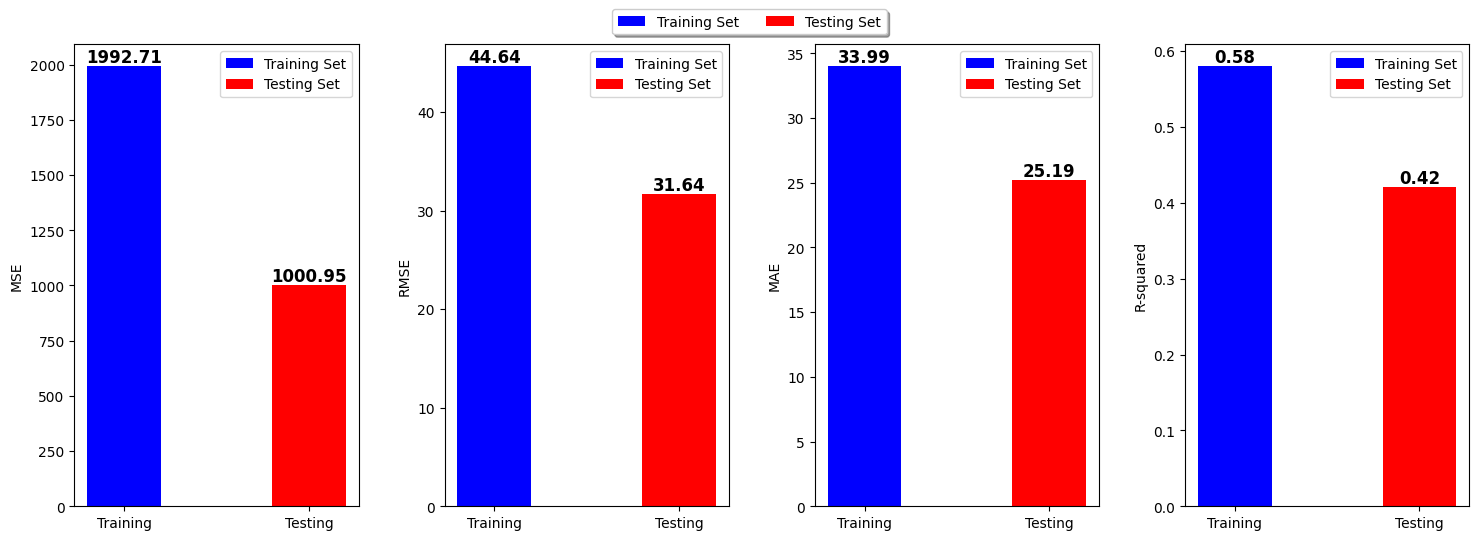

In [5]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared']
train_metrics = [mse_train, rmse_train, mae_train, r2_train]
test_metrics = [mse_test, rmse_test, mae_test, r2_test]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

##### Plot Actual vs Predicted Values

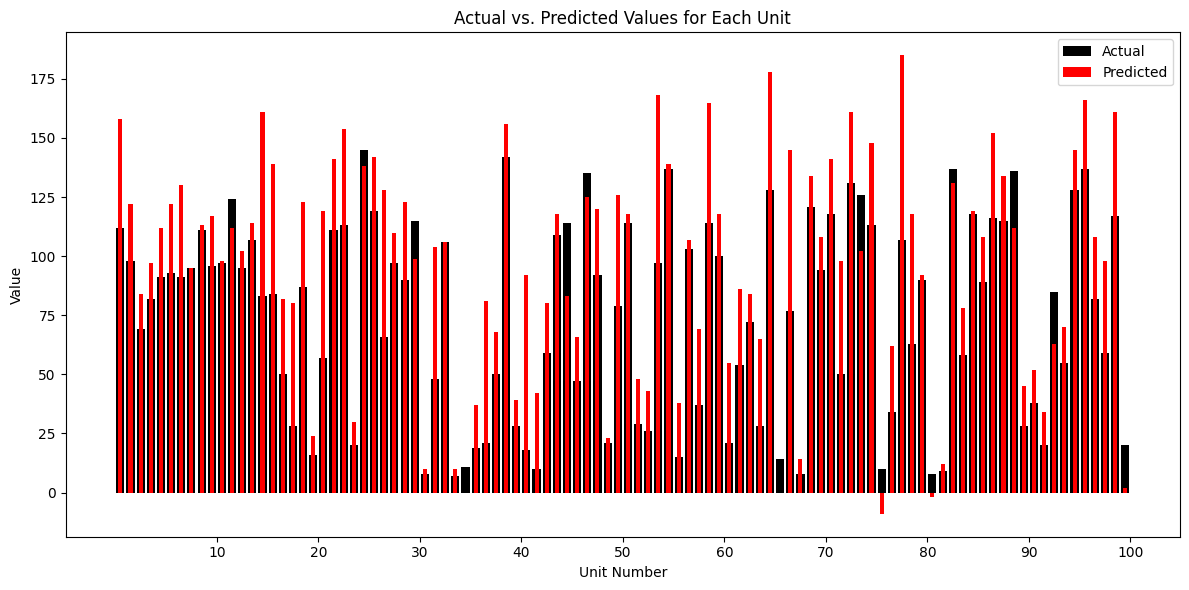

In [6]:
num_units = len(Set1_y_Test)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(Set1_y_Test)
predicted_values = np.squeeze(linear_reg_pred_test_int)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

#### LInear Regression (Dropped Constant, Highly Related Features, Applied Upper RUL Limit)

##### Import Dataset

In [8]:
%store -r FD1_X_Train_sc
%store -r FD1_X_Test_sc
%store -r FD1_y_Train
%store -r FD1_y_Test

%store -r FD1_X_Train
%store -r FD1_X_Test

In [9]:
start = time.time()

FD1_y_Train_array = FD1_y_Train.values.ravel()
FD1_y_Test_array = FD1_y_Test.values.ravel()

linear_reg = LinearRegression()

param_grid = {
    'fit_intercept': [True, False],
    'copy_X': [True, False],
    'n_jobs': [None, -1],  
    'positive': [True, False],
}

grid_search = GridSearchCV(estimator=linear_reg, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(FD1_X_Train, FD1_y_Train_array)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

neg_mse = grid_search.best_score_
print("Negative Mean Squared Error:", neg_mse)

linear_reg_new = grid_search.best_estimator_
end_train = time.time()  

linear_reg_pred_train_new = linear_reg_new.predict(FD1_X_Train)
end_predict = time.time()
linear_reg_pred_test_new = linear_reg_new.predict(FD1_X_Test)
end_predict_test = time.time()

Best Parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}
Negative Mean Squared Error: -467.0168247078842


#### Linear Regression Evaluation

In [10]:
# Mean Squared Error
mse_train_new = mean_squared_error(FD1_y_Train_array, linear_reg_pred_train_new)
mse_test_new = mean_squared_error(FD1_y_Test_array, linear_reg_pred_test_new)

# Root Mean Squared Error
rmse_train_new = np.sqrt(mse_train_new)
rmse_test_new = np.sqrt(mse_test_new)

# Mean Absolute Error
mae_train_new = mean_absolute_error(FD1_y_Train_array, linear_reg_pred_train_new)
mae_test_new = mean_absolute_error(FD1_y_Test_array, linear_reg_pred_test_new)

# R2 Score
r2_train_new = r2_score(FD1_y_Train_array, linear_reg_pred_train_new)
r2_test_new = r2_score(FD1_y_Test_array, linear_reg_pred_test_new)

# Time
fit_time = end_train - start
predict_time_train = end_predict - end_train
predict_time_test = end_predict_test - end_predict
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_new)
print("Root Mean Squared Error:", rmse_train_new)
print("Mean Absolute Error:", mae_train_new)
print("R-squared Score:", r2_train_new)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_new)
print("Root Mean Squared Error:", rmse_test_new)
print("Mean Absolute Error:", mae_test_new)
print("R-squared Score:", r2_test_new)

# Time
print("\n--Fit, Training Times--")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(predict_time_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(predict_time_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 437.542936308785
Root Mean Squared Error: 20.917527012263783
Mean Absolute Error: 16.963466353578617
R-squared Score: 0.768164795090897

--Testing Set Evaluation--
Mean Squared Error: 516.4905101644438
Root Mean Squared Error: 22.726427571539787
Mean Absolute Error: 17.8850426973273
R-squared Score: 0.7009093737219974

--Fit, Training Times--
Time to fit: 0.88 seconds
Time to predict (train set): 0.00 seconds
Time to predict (test set): 0.00 seconds
Total Time: 0.88 seconds


#### Plot Evaluation Results

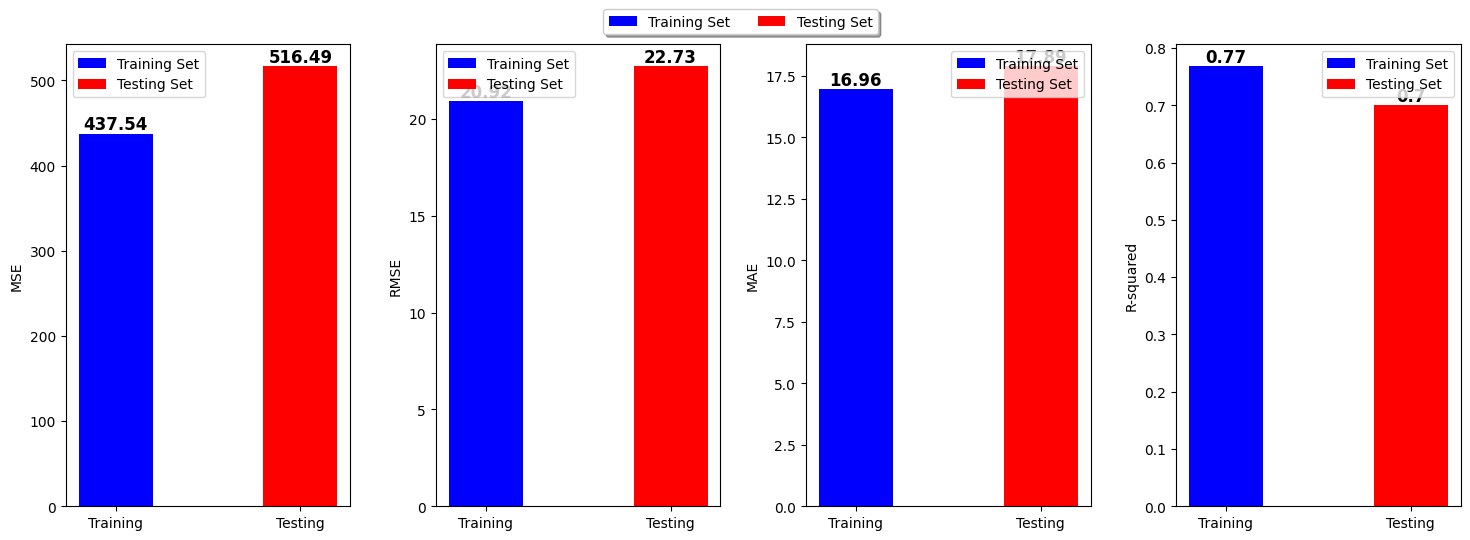

In [11]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared']
train_metrics_2 = [mse_train_new, rmse_train_new, mae_train_new, r2_train_new]
test_metrics_2 = [mse_test_new, rmse_test_new, mae_test_new, r2_test_new]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics_2, test_metrics_2)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

##### Plot Actual vs Predicted Values

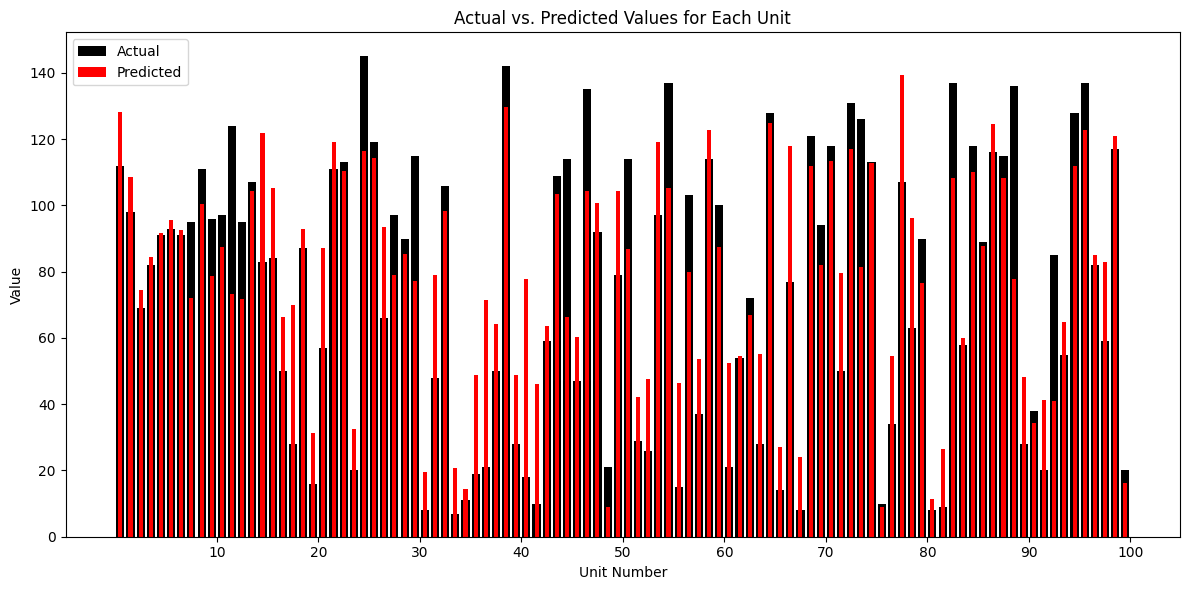

In [12]:
num_units = len(FD1_y_Test_array)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(FD1_y_Test_array)
predicted_values = np.squeeze(linear_reg_pred_test_new)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

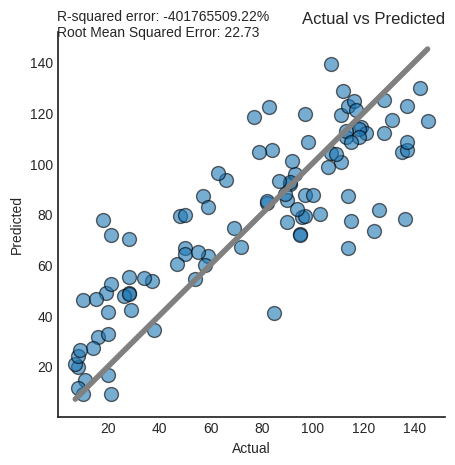

In [13]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=5,5 

fig,ax = plt.subplots()
plt.title('Actual vs Predicted', loc='right')
plt.xlabel('Actual')
plt.ylabel('Predicted')
g = sns.scatterplot(x=FD1_y_Test_array,
                y=linear_reg_pred_test_new,
                s=100,
                alpha=0.6,
                linewidth=1,
                edgecolor='black',
                ax=ax)
f = sns.lineplot(x=[min(FD1_y_Test_array),max(FD1_y_Test_array)],
             y=[min(FD1_y_Test_array),max(FD1_y_Test_array)],
             linewidth=4,
             color='gray',
             ax=ax)

plt.annotate(text=('R-squared error: '+ "{:.2%}".format(linear_reg_new.score(FD1_X_Test_sc,FD1_y_Test_array)) +'\n' +
                  'Root Mean Squared Error: '+ "{:.2f}".format(mean_squared_error(FD1_y_Test_array, linear_reg_pred_test_new,squared=False))),
             xy=(0,150),
             size='medium')

xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
g.set_xticklabels(xlabels)
ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
g.set_yticklabels(ylabels)
sns.despine()

##### Last 5 Cycles from X_Test

In [14]:
%store -r Last_5_X_Test
%store -r Last_5_X_Test_sc

In [15]:
start = time.time()

FD1_y_Train_array = FD1_y_Train.values.ravel()
FD1_y_Test_array = FD1_y_Test.values.ravel()

linear_reg = LinearRegression()

param_grid = {
    'fit_intercept': [True, False],
    'copy_X': [True, False],
    'n_jobs': [None, -1],  
    'positive': [True, False],
}

grid_search = GridSearchCV(estimator=linear_reg, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(FD1_X_Train, FD1_y_Train_array)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

neg_mse = grid_search.best_score_
print("Negative Mean Squared Error:", neg_mse)

linear_reg_new = grid_search.best_estimator_
end_train = time.time()  

linear_reg_pred_train_new = linear_reg_new.predict(FD1_X_Train)
end_predict = time.time()
linear_reg_pred_test_new = linear_reg_new.predict(Last_5_X_Test)
end_predict_test = time.time()

Best Parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}
Negative Mean Squared Error: -467.0168247078842


In [16]:
knn_new_pred_test_reshaped = linear_reg_pred_test_new.reshape(-1, 5)
average_rul_per_group = np.mean(knn_new_pred_test_reshaped, axis=1)

In [17]:
# Mean Squared Error
mse_train_new = mean_squared_error(FD1_y_Train_array, linear_reg_pred_train_new)
mse_test_new = mean_squared_error(FD1_y_Test_array, average_rul_per_group)

# Root Mean Squared Error
rmse_train_new = np.sqrt(mse_train_new)
rmse_test_new = np.sqrt(mse_test_new)

# Mean Absolute Error
mae_train_new = mean_absolute_error(FD1_y_Train_array, linear_reg_pred_train_new)
mae_test_new = mean_absolute_error(FD1_y_Test_array, average_rul_per_group)

# R2 Score
r2_train_new = r2_score(FD1_y_Train_array, linear_reg_pred_train_new)
r2_test_new = r2_score(FD1_y_Test_array, average_rul_per_group)

# Time
fit_time = end_train - start
predict_time_train = end_predict - end_train
predict_time_test = end_predict_test - end_predict
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_new)
print("Root Mean Squared Error:", rmse_train_new)
print("Mean Absolute Error:", mae_train_new)
print("R-squared Score:", r2_train_new)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_new)
print("Root Mean Squared Error:", rmse_test_new)
print("Mean Absolute Error:", mae_test_new)
print("R-squared Score:", r2_test_new)

# Time
print("\n--Fit, Training Times--")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(predict_time_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(predict_time_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 437.542936308785
Root Mean Squared Error: 20.917527012263783
Mean Absolute Error: 16.963466353578617
R-squared Score: 0.768164795090897

--Testing Set Evaluation--
Mean Squared Error: 539.7309902354102
Root Mean Squared Error: 23.23211118765168
Mean Absolute Error: 18.513977296269385
R-squared Score: 0.6874512179521776

--Fit, Training Times--
Time to fit: 0.74 seconds
Time to predict (train set): 0.00 seconds
Time to predict (test set): 0.00 seconds
Total Time: 0.75 seconds
